In [1]:
import requests
from bs4 import BeautifulSoup
from urllib.parse import urljoin
from PIL import Image
from io import BytesIO
from transformers import CLIPProcessor, CLIPModel
import matplotlib.pyplot as plt
import tkinter as tk
from tkinter import filedialog

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
def scrape_images_with_pagination(base_url, max_pages=5):
    """
    Scrapes images from multiple pages, including customer comments.

    :param base_url: The URL of the Yelp page to start scraping.
    :param max_pages: Maximum number of pages to scrape.
    :return: List of tuples (Image object, URL).
    """
    images = []
    seen_urls = set()  # To track unique image URLs
    for page in range(max_pages):
        # Update URL for pagination
        paginated_url = f"{base_url}&start={page * 10}" if "?" in base_url else f"{base_url}?start={page * 10}"
        print(f"Scraping page: {paginated_url}")
        try:
            response = requests.get(paginated_url)
            response.raise_for_status()

            soup = BeautifulSoup(response.text, 'html.parser')
            img_tags = soup.find_all('img')

            print(f"Found {len(img_tags)} images on page {page + 1}.")

            for img_tag in img_tags:
                img_url = img_tag.get('src')
                if not img_url or img_url in seen_urls:
                    continue

                seen_urls.add(img_url)  # Mark this URL as seen
                img_url = urljoin(base_url, img_url)
                if img_url.lower().endswith('.svg'):
                    continue

                try:
                    img_response = requests.get(img_url, stream=True)
                    img_response.raise_for_status()
                    img = Image.open(BytesIO(img_response.content))
                    images.append((img, img_url))
                except Exception as e:
                    print(f"Failed to process {img_url}: {e}")
        except requests.exceptions.RequestException as e:
            print(f"Failed to fetch URL {paginated_url}: {e}")
            break

    print(f"Total unique images scraped across pages: {len(images)}")
    return images

In [3]:
def plot_all_scraped_images(images):
    """
    Plots all scraped images.

    :param images: List of tuples (PIL Image object, URL).
    """
    if not images:
        print("No images to display.")
        return

    num_images = len(images)
    cols = 5
    rows = (num_images + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 3))
    axes = axes.flatten()

    for ax, (img, url) in zip(axes, images):
        ax.imshow(img)
        ax.set_title(url[:30], fontsize=8)
        ax.axis("off")

    # Hide unused subplots
    for ax in axes[len(images):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
def get_top_results(text, images, top_n=5):
    """
    Returns the top N images ranked by similarity to the input text.

    :param text: Input text for similarity ranking.
    :param images: List of tuples (Image object, URL).
    :param top_n: Number of top results to return.
    :return: List of tuples (Image object, URL, score).
    """
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    pil_images = [img for img, _ in images]
    inputs = processor(text=[text], images=pil_images, return_tensors="pt", padding=True)

    outputs = model(**inputs)
    logits_per_image = outputs.logits_per_image
    probs = logits_per_image.softmax(dim=0).squeeze().tolist()

    if isinstance(probs, float):
        probs = [probs]

    sorted_indices = sorted(range(len(probs)), key=lambda i: probs[i], reverse=True)
    return [(images[idx][0], images[idx][1], probs[idx]) for idx in sorted_indices[:top_n]]

In [15]:
# this one works but could not find the same image as the one has the highest similarity
"""
def get_top_results_from_image(input_image, images, top_n=5):

    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    # Extract PIL images from the images list
    pil_images = [img for img, _ in images]

    # Prepare inputs for the processor
    inputs = processor(images=[input_image] + pil_images, return_tensors="pt", padding=True)

    # Use only the vision model for image similarity
    outputs = model.vision_model(pixel_values=inputs["pixel_values"])

    # Compute embeddings
    embeddings = outputs.last_hidden_state.mean(dim=1)  # Average pooling for embeddings
    input_embedding = embeddings[0]
    image_embeddings = embeddings[1:]

    # Compute cosine similarity
    similarity_scores = (input_embedding @ image_embeddings.T).softmax(dim=0).squeeze().tolist()

    # Rank images by similarity
    sorted_indices = sorted(range(len(similarity_scores)), key=lambda i: similarity_scores[i], reverse=True)
    return [(images[idx][0], images[idx][1], similarity_scores[idx]) for idx in sorted_indices[:top_n]]
"""


'\ndef get_top_results_from_image(input_image, images, top_n=5):\n\n    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")\n    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")\n\n    # Extract PIL images from the images list\n    pil_images = [img for img, _ in images]\n\n    # Prepare inputs for the processor\n    inputs = processor(images=[input_image] + pil_images, return_tensors="pt", padding=True)\n\n    # Use only the vision model for image similarity\n    outputs = model.vision_model(pixel_values=inputs["pixel_values"])\n\n    # Compute embeddings\n    embeddings = outputs.last_hidden_state.mean(dim=1)  # Average pooling for embeddings\n    input_embedding = embeddings[0]\n    image_embeddings = embeddings[1:]\n\n    # Compute cosine similarity\n    similarity_scores = (input_embedding @ image_embeddings.T).softmax(dim=0).squeeze().tolist()\n\n    # Rank images by similarity\n    sorted_indices = sorted(range(len(similarity_scores)), key=

In [5]:
def get_top_results_from_image(input_image, images, top_n=5):
    model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

    pil_images = [img for img, _ in images]
    inputs = processor(images=[input_image] + pil_images, return_tensors="pt", padding=True)
    outputs = model.vision_model(pixel_values=inputs["pixel_values"])

    embeddings = outputs.last_hidden_state.mean(dim=1)  # Average pooling for embeddings
    embeddings = torch.nn.functional.normalize(embeddings, p=2, dim=1)  # Normalize embeddings

    input_embedding = embeddings[0]
    image_embeddings = embeddings[1:]

    similarity_scores = torch.matmul(input_embedding, image_embeddings.T).softmax(dim=0).tolist()

    sorted_indices = sorted(range(len(similarity_scores)), key=lambda i: similarity_scores[i], reverse=True)
    return [(images[idx][0], images[idx][1], similarity_scores[idx]) for idx in sorted_indices[:top_n]]


In [6]:
def plot_results(results):
    """
    Plots the top search results with their scores and URLs.

    :param results: List of tuples (Image object, URL, score).
    """
    fig, axes = plt.subplots(1, len(results), figsize=(15, 5))
    for ax, (img, url, score) in zip(axes, results):
        ax.imshow(img)
        ax.set_title(f"Score: {score:.2f}\n{url[:30]}...", fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [7]:
def select_input_image():
    """
    Opens a file dialog to select an image file.

    :return: PIL Image object or None if no file was selected.
    """
    root = tk.Tk()
    root.withdraw()  # Hide the main window

    file_path = filedialog.askopenfilename(
        title="Select an Image File",
        filetypes=[("all files", "*.*")]
    )

    if file_path:
        try:
            image = Image.open(file_path)
            print(f"Selected image: {file_path}")
            return image
        except Exception as e:
            print(f"Error loading image: {e}")
    else:
        print("No file selected.")
    return None

Enter the Yelp URL to scrape images from:  https://www.yelp.com/biz/sparkys-balloons-san-francisco-6?osq=Party+Supplies
Enter the number of pages to scrape:  4


Scraping page: https://www.yelp.com/biz/sparkys-balloons-san-francisco-6?osq=Party+Supplies&start=0
Found 94 images on page 1.
Scraping page: https://www.yelp.com/biz/sparkys-balloons-san-francisco-6?osq=Party+Supplies&start=10
Found 95 images on page 2.
Scraping page: https://www.yelp.com/biz/sparkys-balloons-san-francisco-6?osq=Party+Supplies&start=20
Failed to fetch URL https://www.yelp.com/biz/sparkys-balloons-san-francisco-6?osq=Party+Supplies&start=20: 403 Client Error: Forbidden for url: https://www.yelp.com/biz/sparkys-balloons-san-francisco-6?osq=Party+Supplies&start=20
Total unique images scraped across pages: 56
Total images scraped: 56


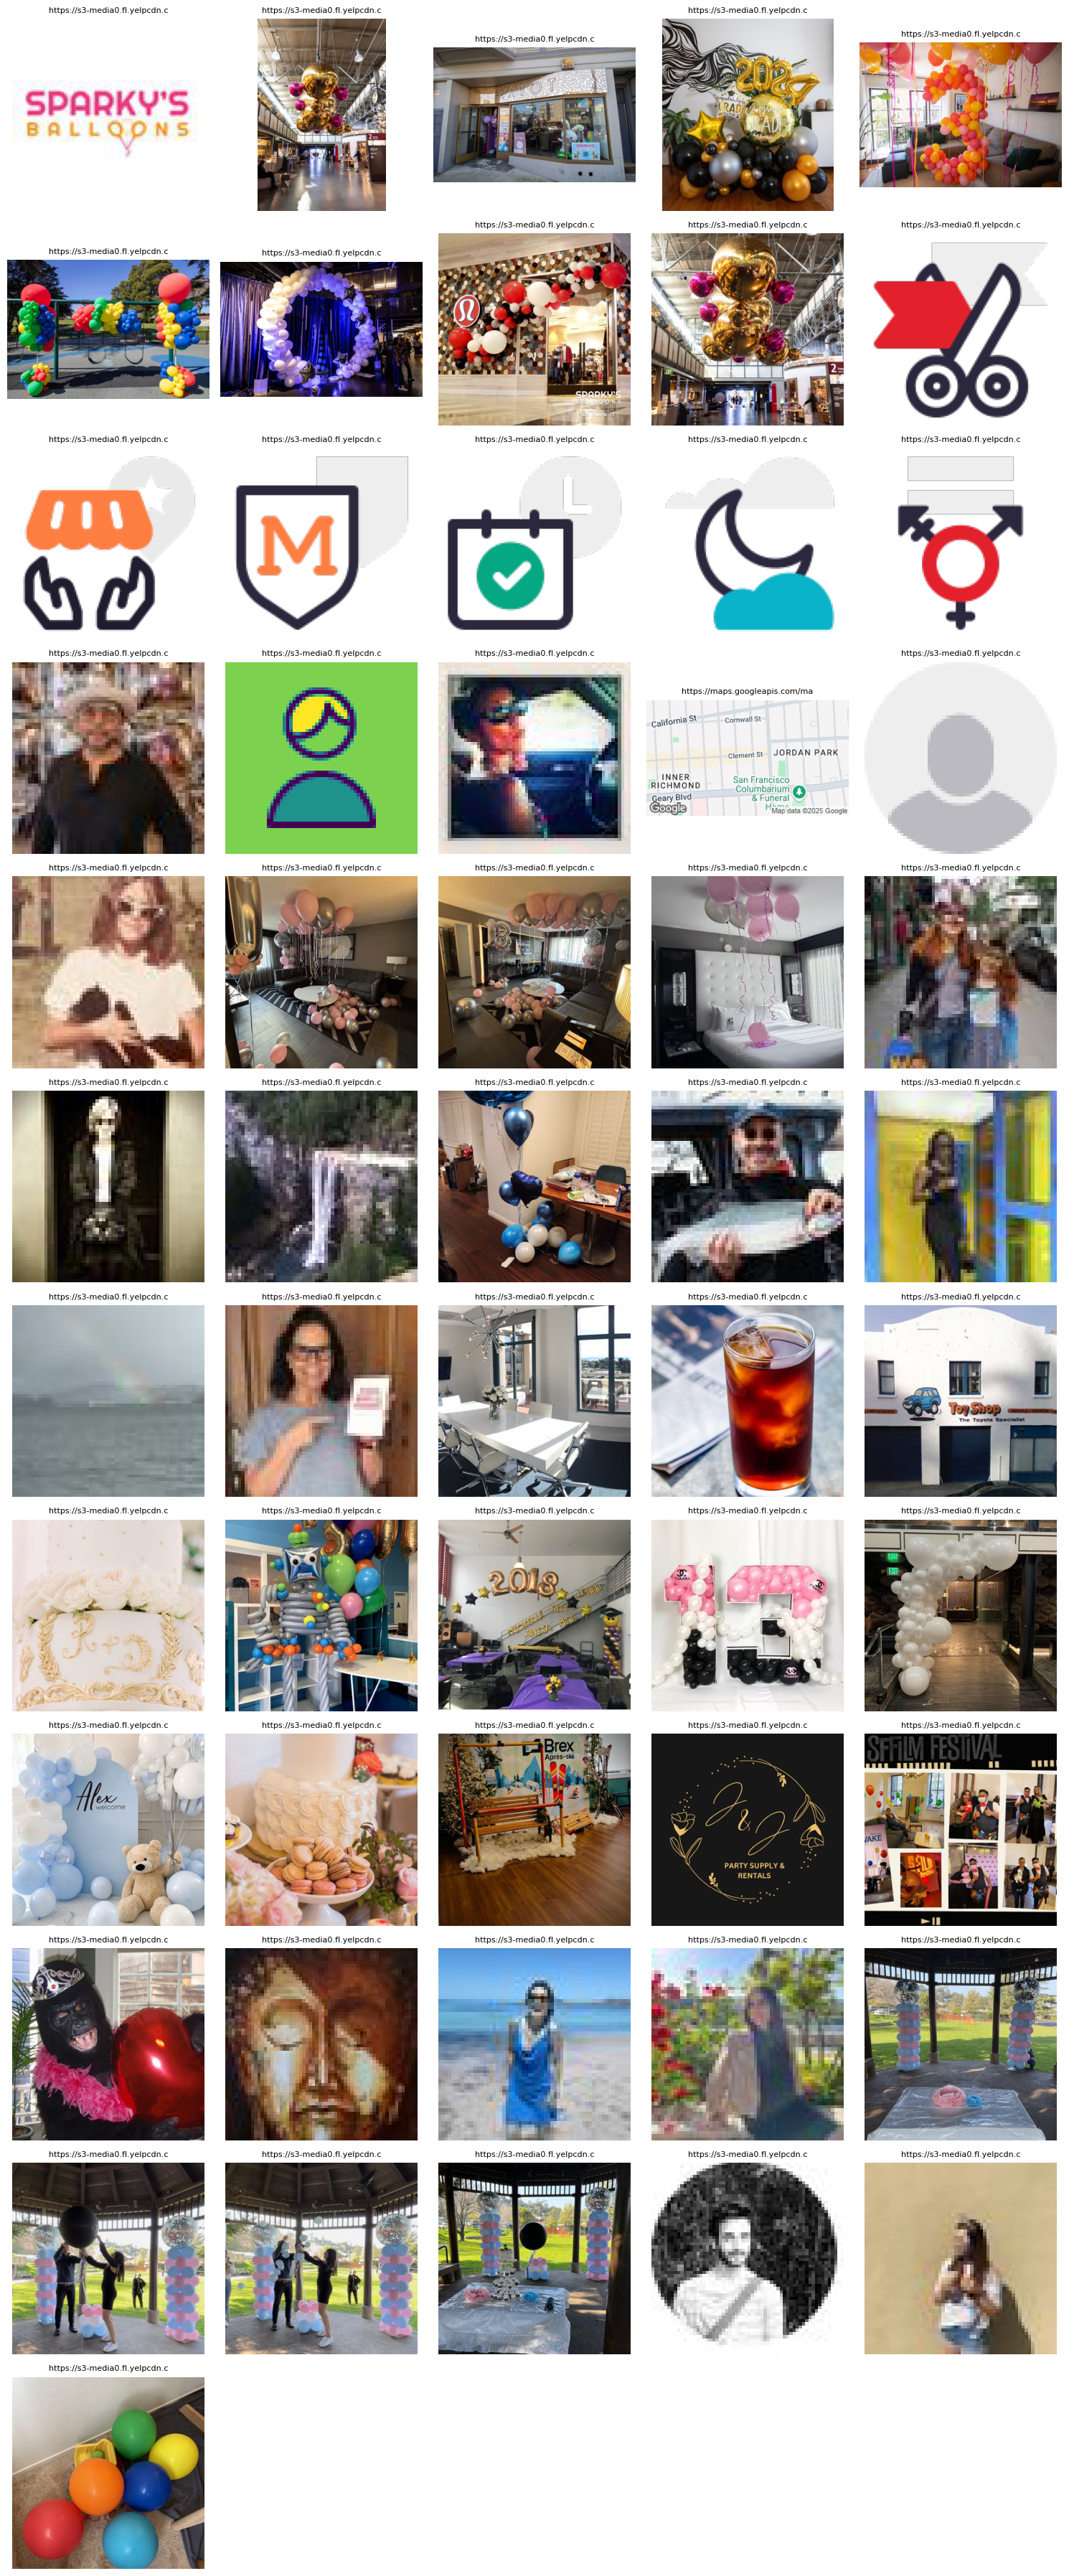

Selected image: /Users/ywang4/Desktop/test_image_6.jpg
Top results found. Displaying...


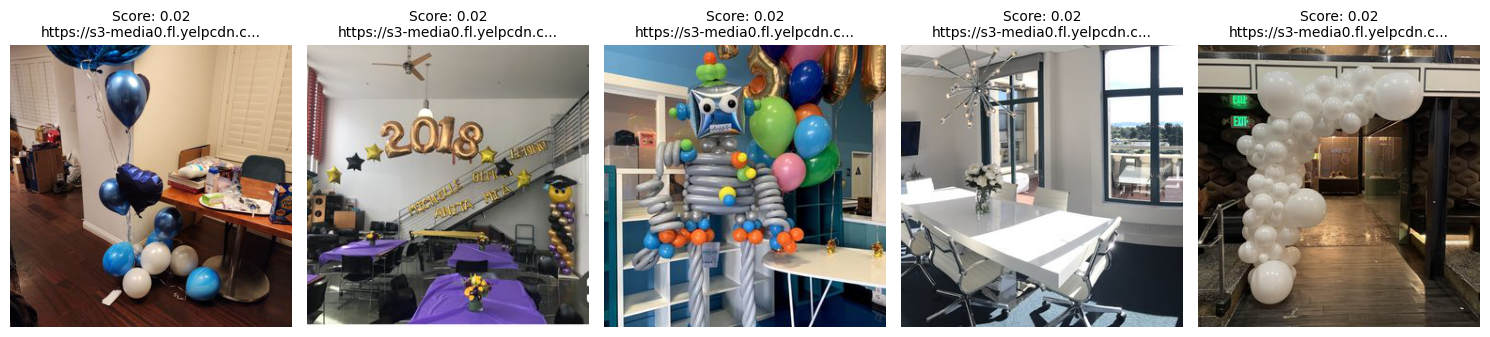

In [8]:
import torch
def main():
    url = input("Enter the Yelp URL to scrape images from: ").strip()
    if not url:
        print("URL input is required.")
        return

    try:
        max_pages = int(input("Enter the number of pages to scrape: "))
    except ValueError:
        print("Invalid input for the number of pages. Please enter an integer.")
        return

    # Scrape images from Yelp
    scraped_images = scrape_images_with_pagination(url, max_pages=max_pages)
    print(f"Total images scraped: {len(scraped_images)}")

    if not scraped_images:
        print("No images found at the provided URL.")
        return

    # Plot all scraped images
    plot_all_scraped_images(scraped_images)

    # Select input image
    input_image = select_input_image()
    if not input_image:
        print("Input image selection is required.")
        return

    # Find top results
    results = get_top_results_from_image(input_image, scraped_images)
    if results:
        print("Top results found. Displaying...")
        plot_results(results)
    else:
        print("No matching results found.")

if __name__ == "__main__":
    main()
